# 02d — Diagnostico LSTM-VAE v3: Analisis de Fallas
## Dataset: SWaT A12 (Marzo 2026)

### Objetivo

El modelo v3 alcanza ROC-AUC=0.7963 y F1max=0.441. La distribucion de errores
muestra que **algunos ataques son faciles de detectar y otros no**. Este
notebook responde sistematicamente:

1. **Inventario de ataques** — tipos, duraciones, sensores objetivo.
2. **Tasa de deteccion por tipo de ataque** — cuales detecta bien el modelo y cuales no.
3. **Contaminacion de ventanas** — cuanto de cada ventana-ataque es realmente anomalo.
4. **Analisis por sensor** — que variables continuas tienen mayor error en ataques.
5. **Score temporal** — visualizacion del score vs etiquetas reales en el tiempo.
6. **Conclusiones** — resumen accionable para el siguiente paso.

> **No se reentrena nada aqui.** Se carga el modelo guardado de v3.


## 0. Imports

In [1]:
import json, joblib, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
import warnings; warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas y configuracion

In [2]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / 'data').exists() else current_dir.parent

RAW_CSV    = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A12_OTDataset_Mar_26' / '11-Mar-2026_0900_1700_labeled.csv'
OPTUNA_CFG = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_a12_optuna_v1' / 'optuna_best_config.json'
MODEL_DIR  = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_a12_v3'
DIAG_DIR   = MODEL_DIR / 'diagnostico'
DIAG_DIR.mkdir(parents=True, exist_ok=True)

print('CSV:', RAW_CSV.exists())
print('Optuna cfg:', OPTUNA_CFG.exists())
print('Model dir:', MODEL_DIR.exists())
print('Diag dir:', DIAG_DIR)


CSV: True
Optuna cfg: True
Model dir: True
Diag dir: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_a12_v3\diagnostico


In [3]:
# Cargar configuracion
with open(OPTUNA_CFG) as f:
    ocfg = json.load(f)

continuous_cols = ocfg['continuous_cols']
discrete_cols   = ocfg['discrete_cols']
feature_cols    = ocfg['feature_cols']
STRIDE          = int(ocfg['stride'])
bp              = ocfg['best_params']

WINDOW_SIZE = int(ocfg['window_size'])
HIDDEN_SIZE = int(bp['hidden_size'])
NUM_LAYERS  = int(bp['num_layers'])
LATENT_DIM  = int(bp['latent_dim'])
DISC_HIDDEN = int(ocfg['disc_hidden'])
BETA        = float(bp['beta'])
ALPHA       = float(bp['alpha'])
DROPOUT     = float(bp['dropout'])
CLIP_VAL    = float(ocfg['clip_val'])

# Cargar tau del modelo guardado
with open(MODEL_DIR / 'tau_dict.json') as f:
    tau_dict = json.load(f)
TAU_F1 = tau_dict['f1_max']  # umbral optimo para F1

print(f'window={WINDOW_SIZE} | stride={STRIDE} | alpha={ALPHA:.3f} | clip={CLIP_VAL}')
print(f'hidden={HIDDEN_SIZE} | layers={NUM_LAYERS} | latent={LATENT_DIM}')
print(f'TAU_F1max={TAU_F1:.4f}')
print(f'cont_cols={len(continuous_cols)} | disc_cols={len(discrete_cols)}')


window=60 | stride=10 | alpha=0.889 | clip=5.0
hidden=192 | layers=1 | latent=96
TAU_F1max=0.2293
cont_cols=31 | disc_cols=31


## 2. Arquitectura y carga del modelo v3

In [4]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, latent_dim, dropout):
        super().__init__()
        self.lstm      = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                                  dropout=dropout if num_layers > 1 else 0.0)
        self.drop      = nn.Dropout(dropout)
        self.fc_mu     = nn.Linear(hidden_size, latent_dim)
        self.fc_logvar = nn.Linear(hidden_size, latent_dim)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        h_last = self.drop(h[-1])
        return self.fc_mu(h_last), self.fc_logvar(h_last)

class LSTMDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_size, num_layers, output_size, seq_len, dropout):
        super().__init__()
        self.seq_len    = seq_len
        self.num_layers = num_layers
        self.fc_h0      = nn.Linear(latent_dim, hidden_size)
        self.lstm       = nn.LSTM(latent_dim, hidden_size, num_layers, batch_first=True,
                                   dropout=dropout if num_layers > 1 else 0.0)
        self.drop       = nn.Dropout(dropout)
        self.fc_out     = nn.Linear(hidden_size, output_size)
    def forward(self, z):
        h0 = torch.tanh(self.fc_h0(z)).unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(z.unsqueeze(1).repeat(1, self.seq_len, 1), (h0, c0))
        return self.fc_out(self.drop(out))

class HybridLSTMVAE(nn.Module):
    def __init__(self, cont_size, seq_len, disc_dim,
                 hidden_size=128, num_layers=2, latent_dim=64, disc_hidden=64, dropout=0.2):
        super().__init__()
        self.encoder_cont = LSTMEncoder(cont_size, hidden_size, num_layers, latent_dim, dropout)
        self.decoder_cont = LSTMDecoder(latent_dim, hidden_size, num_layers, cont_size, seq_len, dropout)
        self.encoder_disc = nn.Sequential(
            nn.Linear(disc_dim, disc_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(disc_hidden, disc_hidden // 2), nn.ReLU())
        self.decoder_disc = nn.Sequential(
            nn.Linear(disc_hidden // 2, disc_hidden), nn.ReLU(),
            nn.Linear(disc_hidden, disc_dim))
    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return mu
    def forward(self, xc, xd):
        mu, logvar = self.encoder_cont(xc)
        z = self.reparameterize(mu, logvar)
        return self.decoder_cont(z), self.decoder_disc(self.encoder_disc(xd)), mu, logvar


In [5]:
# Necesitamos conocer las dimensiones antes de instanciar el modelo.
# Cargamos el scaler y reconstruimos disc_dim a partir del numero de variables discretas
scaler_cont = joblib.load(MODEL_DIR / 'scaler_cont.pkl')
disc_max    = pd.Series(joblib.load(MODEL_DIR / 'disc_max_dict.pkl'))

CONT_SIZE = len(continuous_cols)
DISC_DIM  = len(discrete_cols) * 4   # 4 features por variable discreta (mode, transitions, nunique, dominance)

model = HybridLSTMVAE(
    cont_size   = CONT_SIZE,
    seq_len     = WINDOW_SIZE,
    disc_dim    = DISC_DIM,
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    latent_dim  = LATENT_DIM,
    disc_hidden = DISC_HIDDEN,
    dropout     = DROPOUT,
).to(device)

model.load_state_dict(torch.load(MODEL_DIR / 'model_state.pt', map_location=device))
model.eval()
print(f'Modelo v3 cargado correctamente.')
print(f'Parametros: {sum(p.numel() for p in model.parameters()):,}')


Modelo v3 cargado correctamente.
Parametros: 477,435


## 3. Carga completa del CSV con metadatos de ataques

A diferencia de los notebooks de entrenamiento, aqui cargamos **todas** las
columnas de metadatos: `attack_id`, `attack_name`, `attack_targets`,
`attack_start_time`, `attack_end_time`. Son las que permiten el diagnostico
por tipo de ataque.

In [6]:
META_COLS = ['t_stamp','attack_label','attack_id','attack_name','attack_targets',
             'attack_start_time','attack_end_time']

df_raw = pd.read_csv(RAW_CSV, low_memory=False)
df_raw['t_stamp']      = pd.to_datetime(df_raw['t_stamp'], errors='coerce')
df_raw['attack_label'] = pd.to_numeric(df_raw['attack_label'], errors='coerce').fillna(0).astype(int)
df_raw = df_raw.sort_values('t_stamp').reset_index(drop=True)

# Limpiar feature_cols
for col in feature_cols:
    df_raw[col] = pd.to_numeric(df_raw[col].replace('Bad Input', np.nan), errors='coerce')

# Rellenar NaN con modas del tramo normal (warmup ya fue aplicado en el scaler)
df_normal = df_raw[df_raw['attack_label'] == 0]
modes_ref  = df_normal[feature_cols].mode().iloc[0]
df_raw[feature_cols] = df_raw[feature_cols].fillna(modes_ref)

# Dataframe completo escalado (para scores)
df_sc = df_raw[['t_stamp','attack_label'] + feature_cols].copy()
df_sc[continuous_cols] = np.clip(
    scaler_cont.transform(df_sc[continuous_cols].values), -CLIP_VAL, CLIP_VAL
)
df_sc[discrete_cols] = (df_sc[discrete_cols] / disc_max).clip(0, 1)

# Dataframe de metadatos (para diagnostico por tipo)
meta_avail = [c for c in META_COLS if c in df_raw.columns]
df_meta = df_raw[meta_avail].copy()

n_normal = (df_raw['attack_label'] == 0).sum()
n_attack = (df_raw['attack_label'] == 1).sum()
print(f'Total filas: {len(df_raw):,} | Normal: {n_normal:,} | Ataque: {n_attack:,} ({100*n_attack/len(df_raw):.1f}%)')
if 'attack_id' in df_meta.columns:
    print(f'Tipos de ataque unicos (attack_id): {df_meta[df_meta["attack_label"]==1]["attack_id"].nunique()}')
if 'attack_name' in df_meta.columns:
    print(f'Nombres de ataque unicos: {df_meta[df_meta["attack_label"]==1]["attack_name"].nunique()}')


Total filas: 28,860 | Normal: 25,740 | Ataque: 3,120 (10.8%)
Tipos de ataque unicos (attack_id): 11
Nombres de ataque unicos: 10


## 4. Ventanas con metadatos

Construimos las ventanas del CSV completo enriquecidas con:
- `y`: etiqueta (1 si hay algun timestep de ataque en la ventana)
- `attack_frac`: fraccion de timesteps de ataque dentro de la ventana
- `attack_id_mode`: `attack_id` mas frecuente en la ventana
- `attack_name_mode`: nombre del ataque mas frecuente
- `t_start`: timestamp de inicio de la ventana


In [7]:
def create_windows(arr, ws, stride):
    wins = [arr[i:i+ws] for i in range(0, len(arr)-ws+1, stride)]
    return np.array(wins, dtype=np.float32) if wins else np.empty((0, ws, arr.shape[1]), dtype=np.float32)

def summarize_discrete_windows(disc_windows, dcols):
    rows = []
    for w in disc_windows:
        feats = {}
        for j, col in enumerate(dcols):
            v = w[:, j]; s = pd.Series(v)
            feats[f'{col}__mode']        = s.mode().iloc[0] if len(s.mode()) > 0 else 0.0
            feats[f'{col}__transitions'] = float(np.sum(v[1:] != v[:-1]))
            feats[f'{col}__nunique']     = float(len(np.unique(v)))
            feats[f'{col}__dominance']   = float(s.value_counts(normalize=True).iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)

cont_arr  = df_sc[continuous_cols].values.astype(np.float32)
disc_arr  = df_sc[discrete_cols].values.astype(np.float32)
labs_arr  = df_sc['attack_label'].values
tstamp_arr= df_sc['t_stamp'].values

# Metadatos por fila
aid_arr  = df_meta['attack_id'].values   if 'attack_id'   in df_meta.columns else np.zeros(len(df_meta))
aname_arr= df_meta['attack_name'].values if 'attack_name' in df_meta.columns else np.full(len(df_meta), 'unknown')
atgt_arr = df_meta['attack_targets'].values if 'attack_targets' in df_meta.columns else np.full(len(df_meta), '')

wins_c, wins_d = [], []
meta_rows = []

for s in range(0, len(cont_arr) - WINDOW_SIZE + 1, STRIDE):
    wins_c.append(cont_arr[s:s+WINDOW_SIZE])
    wins_d.append(disc_arr[s:s+WINDOW_SIZE])

    seg_labs = labs_arr[s:s+WINDOW_SIZE]
    seg_aids = aid_arr[s:s+WINDOW_SIZE]
    seg_anms = aname_arr[s:s+WINDOW_SIZE]

    atk_frac = float(np.mean(seg_labs == 1))
    # attack_id y name dominante (o 0/'' si todo normal)
    atk_ids  = seg_aids[seg_labs == 1]
    atk_nms  = seg_anms[seg_labs == 1]
    if len(atk_ids) > 0:
        uid, cnt = np.unique(atk_ids, return_counts=True)
        aid_mode = uid[cnt.argmax()]
        unm, cnm = np.unique(atk_nms, return_counts=True)
        anm_mode = unm[cnm.argmax()]
    else:
        aid_mode, anm_mode = 0, 'normal'

    meta_rows.append({
        'y'           : int(np.any(seg_labs == 1)),
        'attack_frac' : atk_frac,
        'attack_id'   : aid_mode,
        'attack_name' : str(anm_mode),
        't_start'     : tstamp_arr[s],
    })

X_eval_c = np.array(wins_c, dtype=np.float32)
X_eval_d = summarize_discrete_windows(np.array(wins_d, dtype=np.float32), discrete_cols).values.astype(np.float32)
df_wins  = pd.DataFrame(meta_rows)

print(f'Ventanas totales: {len(df_wins):,}')
print(f'  Normal (y=0): {(df_wins["y"]==0).sum():,}')
print(f'  Ataque (y=1): {(df_wins["y"]==1).sum():,}  ({100*df_wins["y"].mean():.1f}%)')
print(f'  Tipos de ataque en ventanas: {df_wins[df_wins["y"]==1]["attack_id"].nunique()}')


Ventanas totales: 2,881
  Normal (y=0): 2,519
  Ataque (y=1): 362  (12.6%)
  Tipos de ataque en ventanas: 11


## 5. Calcular scores con errores por sensor

Ademas del score combinado, calculamos el error de reconstruccion
**por variable continua** — esto permite identificar que sensores
contribuyen mas al error en ventanas de ataque.

In [8]:
def recon_errors_full(model, Xc, Xd, alpha, bs=256):
    """Retorna:
    - ec      : (N,)       MSE continuo por ventana
    - ed      : (N,)       MSE discreto por ventana
    - scores  : (N,)       score combinado
    - ec_per_feat : (N, C) MSE por feature continua por ventana
    """
    loader = DataLoader(
        TensorDataset(torch.tensor(Xc, dtype=torch.float32),
                      torch.tensor(Xd, dtype=torch.float32)),
        batch_size=bs, shuffle=False
    )
    ec_l, ed_l, ec_feat_l = [], [], []
    model.eval()
    with torch.no_grad():
        for xc, xd in loader:
            xc, xd = xc.to(device), xd.to(device)
            xc_hat, xd_hat, mu, _ = model(xc, xd)
            # MSE por ventana (media sobre T y C)
            ec_l.extend(torch.mean((xc_hat - xc)**2, dim=(1, 2)).cpu().numpy())
            ed_l.extend(torch.mean((xd_hat - xd)**2, dim=1).cpu().numpy())
            # MSE por feature: media sobre T, conservar C
            ec_feat_l.append(torch.mean((xc_hat - xc)**2, dim=1).cpu().numpy())  # (B, C)
    ec = np.array(ec_l)
    ed = np.array(ed_l)
    ec_per_feat = np.vstack(ec_feat_l)  # (N, C)
    return ec, ed, alpha * ec + (1 - alpha) * ed, ec_per_feat

ec, ed, scores, ec_per_feat = recon_errors_full(model, X_eval_c, X_eval_d, ALPHA)
df_wins['score'] = scores
df_wins['ec']    = ec
df_wins['ed']    = ed
df_wins['pred']  = (scores > TAU_F1).astype(int)
df_wins['tp']    = ((df_wins['pred']==1) & (df_wins['y']==1)).astype(int)
df_wins['fp']    = ((df_wins['pred']==1) & (df_wins['y']==0)).astype(int)
df_wins['fn']    = ((df_wins['pred']==0) & (df_wins['y']==1)).astype(int)
df_wins['tn']    = ((df_wins['pred']==0) & (df_wins['y']==0)).astype(int)

y = df_wins['y'].values
auc = roc_auc_score(y, scores)
tp  = df_wins['tp'].sum(); fp = df_wins['fp'].sum()
fn  = df_wins['fn'].sum(); tn = df_wins['tn'].sum()
prec = tp/(tp+fp+1e-10); rec = tp/(tp+fn+1e-10)
f1   = 2*prec*rec/(prec+rec+1e-10)
fpr  = fp/(fp+tn+1e-10)

print(f'Verificacion global (tau={TAU_F1:.4f}):')
print(f'  ROC-AUC={auc:.4f} | F1={f1:.3f} | Recall={rec:.3f} | Precision={prec:.3f} | FPR={fpr:.3f}')
print(f'  TP={tp} | FP={fp} | FN={fn} | TN={tn}')


Verificacion global (tau=0.2293):
  ROC-AUC=0.7963 | F1=0.440 | Recall=0.685 | Precision=0.324 | FPR=0.206
  TP=248 | FP=518 | FN=114 | TN=2001


## ANALISIS 1 — Inventario de ataques

Tabla resumen de cada tipo de ataque: duracion total, numero de ventanas,
y sensores objetivo.

In [9]:
# Inventario desde el CSV original (nivel de timestep)
df_atk_raw = df_raw[df_raw['attack_label'] == 1].copy()

if 'attack_id' in df_atk_raw.columns:
    inv_rows = []
    for aid, grp in df_atk_raw.groupby('attack_id'):
        dur_s    = len(grp)  # duracion en segundos (1Hz)
        name     = grp['attack_name'].mode().iloc[0] if 'attack_name' in grp.columns else 'N/A'
        targets  = grp['attack_targets'].mode().iloc[0] if 'attack_targets' in grp.columns else 'N/A'
        n_wins   = (df_wins[df_wins['attack_id'] == aid]['y'] == 1).sum()
        inv_rows.append({'attack_id': aid, 'attack_name': name,
                         'dur_seg': dur_s, 'n_ventanas': n_wins,
                         'targets': targets})

    df_inv = pd.DataFrame(inv_rows).sort_values('attack_id')
    print(f'=== INVENTARIO DE ATAQUES ({len(df_inv)} tipos) ===')
    pd.set_option('display.max_colwidth', 60)
    display(df_inv.to_string(index=False))
else:
    print('Columna attack_id no disponible — mostrando solo conteos por etiqueta')
    print(df_atk_raw.describe())


=== INVENTARIO DE ATAQUES (11 tipos) ===


' attack_id                                                                        attack_name  dur_seg  n_ventanas           targets\n       1.0                       Stage 5 Valve Manipulation — MV503/504 Open, MV501/502 Close      300          35         MV501–504\n       2.0                             Stage 1 Flow Disruption — MV101 Open, P101 & P102 Stop      300          35 MV101, P101, P102\n       3.0            Florida Water Plant Scenario — Dosing Pump Activation & Sensor Spoofing      300          35  P201–P206, MV201\n       4.0                       Tank Overflow via LIT101 Spoofing — Schneider Demo Attack 01      300          35            LIT101\n       5.0              Stage 5 Valve Manipulation — MV503/504 Open, MV501/502 Close (Repeat)      300          35         MV501–504\n       6.0                       Tank Overflow via LIT101 Spoofing — Schneider Demo Attack 01      120          15            LIT101\n       7.0                       Stage 2 Parallel Pump Overri

## ANALISIS 2 — Tasa de deteccion por tipo de ataque

Para cada tipo de ataque: cuantas ventanas se detectan vs no se detectan
al umbral TAU_F1max. Ordena de peor a mejor deteccion.

In [10]:
df_atk_wins = df_wins[df_wins['y'] == 1].copy()

detect_rows = []
for aid, grp in df_atk_wins.groupby('attack_id'):
    n_total  = len(grp)
    n_detect = grp['pred'].sum()
    n_miss   = n_total - n_detect
    det_rate = n_detect / n_total if n_total > 0 else 0
    name     = grp['attack_name'].mode().iloc[0] if grp['attack_name'].nunique() > 0 else 'N/A'
    avg_frac = grp['attack_frac'].mean()
    avg_score= grp['score'].mean()
    detect_rows.append({
        'attack_id'     : aid,
        'attack_name'   : name,
        'n_ventanas'    : n_total,
        'detectadas'    : int(n_detect),
        'perdidas'      : int(n_miss),
        'det_rate'      : round(det_rate, 3),
        'avg_atk_frac'  : round(avg_frac, 3),
        'avg_score'     : round(avg_score, 4),
    })

df_det = pd.DataFrame(detect_rows).sort_values('det_rate')
print('=== DETECCION POR TIPO DE ATAQUE (tau=TAU_F1max) ===')
print(df_det.to_string(index=False))

# Guardar como CSV para referencia
df_det.to_csv(DIAG_DIR / 'deteccion_por_tipo.csv', index=False)


=== DETECCION POR TIPO DE ATAQUE (tau=TAU_F1max) ===
 attack_id                                                                        attack_name  n_ventanas  detectadas  perdidas  det_rate  avg_atk_frac  avg_score
       1.0                       Stage 5 Valve Manipulation — MV503/504 Open, MV501/502 Close          35           0        35     0.000         0.857     0.0239
       2.0                             Stage 1 Flow Disruption — MV101 Open, P101 & P102 Stop          35           0        35     0.000         0.857     0.0996
       8.0                       Reverse Osmosis Backwash Diversion — MV302 Close, MV303 Open          35          14        21     0.400         0.857     0.2272
       5.0              Stage 5 Valve Manipulation — MV503/504 Open, MV501/502 Close (Repeat)          35          18        17     0.514         0.857     0.2498
      11.0                                       AIT402 High-Value Spoof Start – Using script          35          29         6     

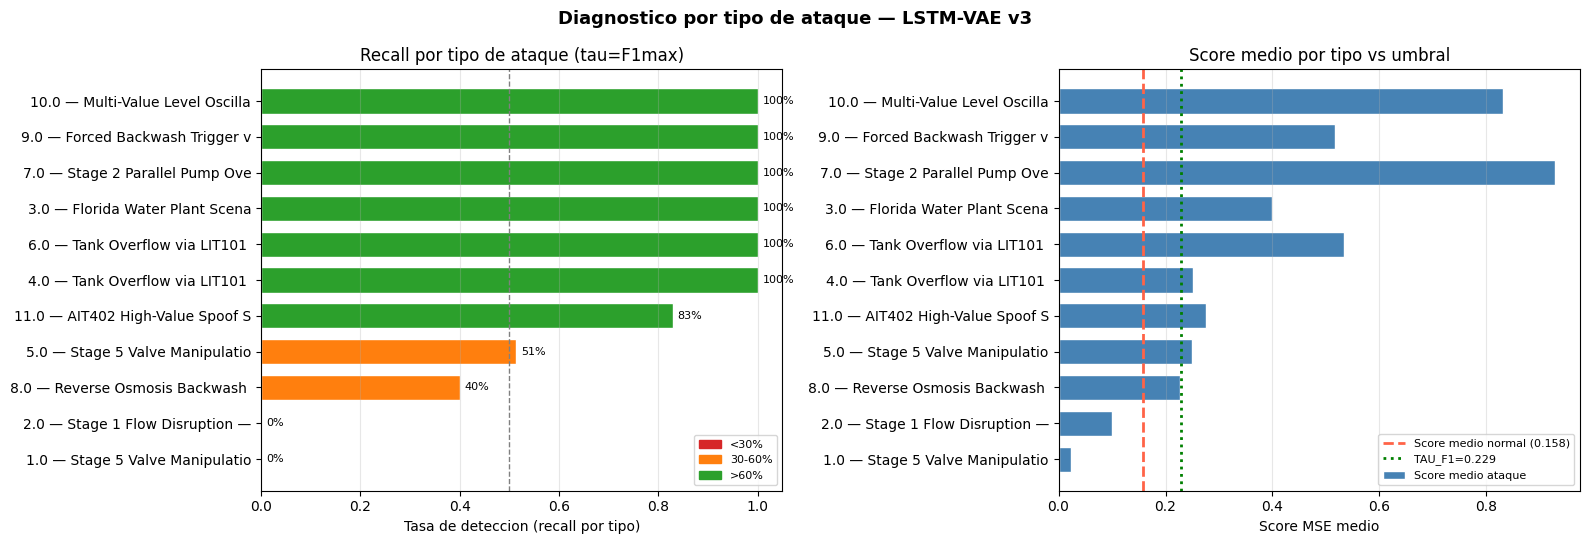

In [11]:
# Grafica: tasa de deteccion por tipo de ataque
fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(df_det)*0.5)))

labels = [f'{row["attack_id"]} — {str(row["attack_name"])[:25]}'
          for _, row in df_det.iterrows()]
colors  = ['#d62728' if r < 0.3 else '#ff7f0e' if r < 0.6 else '#2ca02c'
           for r in df_det['det_rate']]

bars = axes[0].barh(labels, df_det['det_rate'], color=colors, edgecolor='white', height=0.7)
axes[0].axvline(0.5, color='gray', linestyle='--', lw=1, label='50%')
axes[0].set_xlabel('Tasa de deteccion (recall por tipo)')
axes[0].set_title('Recall por tipo de ataque (tau=F1max)')
axes[0].set_xlim(0, 1.05)
for bar, val in zip(bars, df_det['det_rate']):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.0%}', va='center', fontsize=8)
red_p   = mpatches.Patch(color='#d62728', label='<30%')
orange_p= mpatches.Patch(color='#ff7f0e', label='30-60%')
green_p = mpatches.Patch(color='#2ca02c', label='>60%')
axes[0].legend(handles=[red_p, orange_p, green_p], fontsize=8)
axes[0].grid(True, alpha=0.3, axis='x')

# Score medio por tipo de ataque vs score medio normal
mean_normal = df_wins[df_wins['y']==0]['score'].mean()
axes[1].barh(labels, df_det['avg_score'], color='steelblue', edgecolor='white', height=0.7, label='Score medio ataque')
axes[1].axvline(mean_normal, color='tomato', linestyle='--', lw=2, label=f'Score medio normal ({mean_normal:.3f})')
axes[1].axvline(TAU_F1, color='green', linestyle=':', lw=2, label=f'TAU_F1={TAU_F1:.3f}')
axes[1].set_xlabel('Score MSE medio')
axes[1].set_title('Score medio por tipo vs umbral')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Diagnostico por tipo de ataque — LSTM-VAE v3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(DIAG_DIR / 'deteccion_por_tipo.png'), dpi=130, bbox_inches='tight')
plt.show()


## ANALISIS 3 — Contaminacion de ventanas

`attack_frac` mide que fraccion de una ventana es realmente anomala.
Si la mayoria de las ventanas de ataque tienen `attack_frac < 0.3`,
el ataque es corto y queda diluido en los 60 segundos de la ventana.

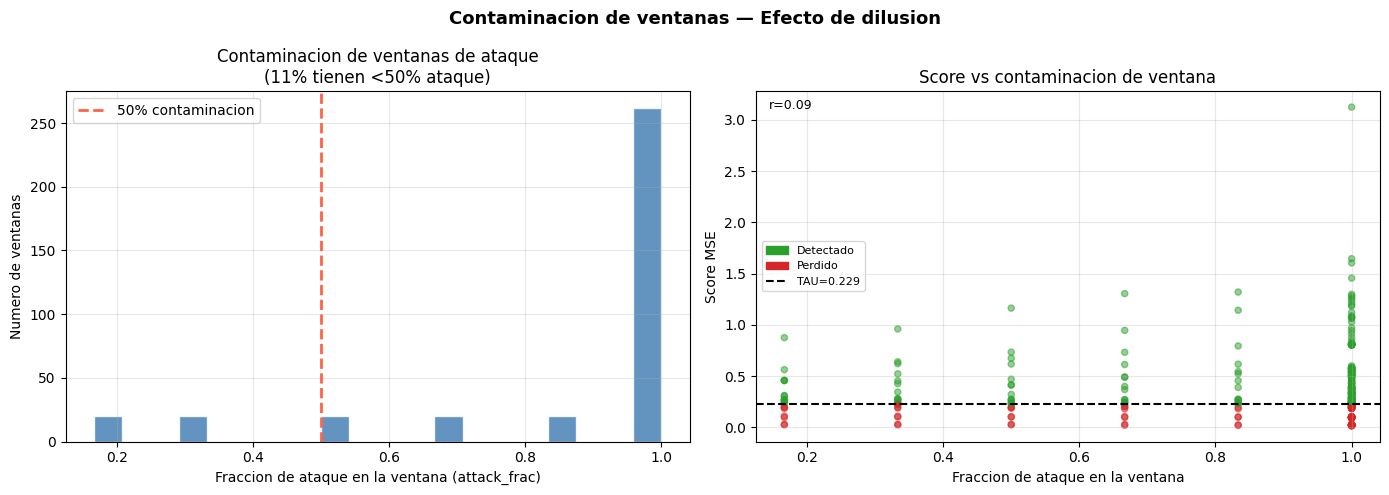

Correlacion attack_frac vs score: 0.088
Ventanas con attack_frac >= 0.5: 322 -> recall en este subgrupo: 0.689
Ventanas con attack_frac <  0.5: 40 -> recall en este subgrupo: 0.650


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de attack_frac para todas las ventanas de ataque
axes[0].hist(df_atk_wins['attack_frac'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0.5, color='tomato', linestyle='--', lw=2, label='50% contaminacion')
pct_under50 = (df_atk_wins['attack_frac'] < 0.5).mean()
axes[0].set_xlabel('Fraccion de ataque en la ventana (attack_frac)')
axes[0].set_ylabel('Numero de ventanas')
axes[0].set_title(f'Contaminacion de ventanas de ataque\n({pct_under50:.0%} tienen <50% ataque)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Score vs attack_frac — scatter con color por deteccion
det_col = df_atk_wins['pred'].map({1: '#2ca02c', 0: '#d62728'})
axes[1].scatter(df_atk_wins['attack_frac'], df_atk_wins['score'],
                c=det_col, alpha=0.5, s=20)
axes[1].axhline(TAU_F1, color='black', linestyle='--', lw=1.5, label=f'TAU={TAU_F1:.3f}')
det_p  = mpatches.Patch(color='#2ca02c', label='Detectado')
miss_p = mpatches.Patch(color='#d62728', label='Perdido')
axes[1].legend(handles=[det_p, miss_p, plt.Line2D([0],[0], color='black', linestyle='--', label=f'TAU={TAU_F1:.3f}')],
               fontsize=8)
axes[1].set_xlabel('Fraccion de ataque en la ventana')
axes[1].set_ylabel('Score MSE')
axes[1].set_title('Score vs contaminacion de ventana')
axes[1].grid(True, alpha=0.3)

# Calcular la correlacion
corr = df_atk_wins[['attack_frac','score']].corr().iloc[0,1]
axes[1].text(0.02, 0.95, f'r={corr:.2f}', transform=axes[1].transAxes, fontsize=9)

plt.suptitle('Contaminacion de ventanas — Efecto de dilusion', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(DIAG_DIR / 'contaminacion_ventanas.png'), dpi=130, bbox_inches='tight')
plt.show()

print(f'Correlacion attack_frac vs score: {corr:.3f}')
print(f'Ventanas con attack_frac >= 0.5: {(df_atk_wins["attack_frac"]>=0.5).sum()} '
      f'-> recall en este subgrupo: {df_atk_wins[df_atk_wins["attack_frac"]>=0.5]["pred"].mean():.3f}')
print(f'Ventanas con attack_frac <  0.5: {(df_atk_wins["attack_frac"]<0.5).sum()} '
      f'-> recall en este subgrupo: {df_atk_wins[df_atk_wins["attack_frac"]<0.5]["pred"].mean():.3f}')


## ANALISIS 4 — Error de reconstruccion por sensor

Para las ventanas de ataque vs ventanas normales: que sensores
continuos tienen mayor error de reconstruccion. Los sensores con
mayor diferencia de error (ataque - normal) son los mas informativos
para la deteccion de esta arquitectura.

In [13]:
# Error medio por sensor en ventanas normales vs ataque
mask_n = (df_wins['y'] == 0).values
mask_a = (df_wins['y'] == 1).values

mean_err_normal = ec_per_feat[mask_n].mean(axis=0)  # (C,)
mean_err_attack = ec_per_feat[mask_a].mean(axis=0)  # (C,)
delta_err       = mean_err_attack - mean_err_normal

df_sensor = pd.DataFrame({
    'sensor'      : continuous_cols,
    'mse_normal'  : mean_err_normal,
    'mse_attack'  : mean_err_attack,
    'delta'       : delta_err,
    'ratio'       : mean_err_attack / (mean_err_normal + 1e-10)
}).sort_values('delta', ascending=False)

TOP_N = 20
df_top = df_sensor.head(TOP_N)
df_bot = df_sensor.tail(10)

print(f'Top {TOP_N} sensores con mayor delta de error (ataque - normal):')
print(df_top[['sensor','mse_normal','mse_attack','delta','ratio']].to_string(index=False))

# Guardar tabla completa
df_sensor.to_csv(DIAG_DIR / 'error_por_sensor.csv', index=False)


Top 20 sensores con mayor delta de error (ataque - normal):
    sensor  mse_normal  mse_attack    delta     ratio
DPIT301.Pv    0.057607    1.923914 1.866306 33.397007
 LIT601.Pv    0.092302    0.793517 0.701216  8.596980
 LIT101.Pv    0.230559    0.889909 0.659350  3.859791
 FIT504.Pv    0.863458    1.521135 0.657677  1.761679
 FIT301.Pv    0.065332    0.697035 0.631704 10.669189
 FIT602.Pv    0.228545    0.765768 0.537222  3.350615
 AIT303.Pv    0.472497    1.002715 0.530218  2.122161
 PIT502.Pv    0.395183    0.920397 0.525214  2.329039
 AIT503.Pv    0.204662    0.639042 0.434380  3.122423
 AIT201.Pv    0.156930    0.432735 0.275805  2.757500
 AIT501.Pv    0.154469    0.405817 0.251348  2.627174
 AIT202.Pv    0.169759    0.341621 0.171862  2.012392
 FIT201.Pv    0.141800    0.303567 0.161767  2.140814
 LIT301.Pv    0.112362    0.266549 0.154187  2.372234
 LIT401.Pv    0.191456    0.338915 0.147459  1.770199
 AIT302.Pv    0.129972    0.254816 0.124844  1.960544
 FIT503.Pv    0.093819

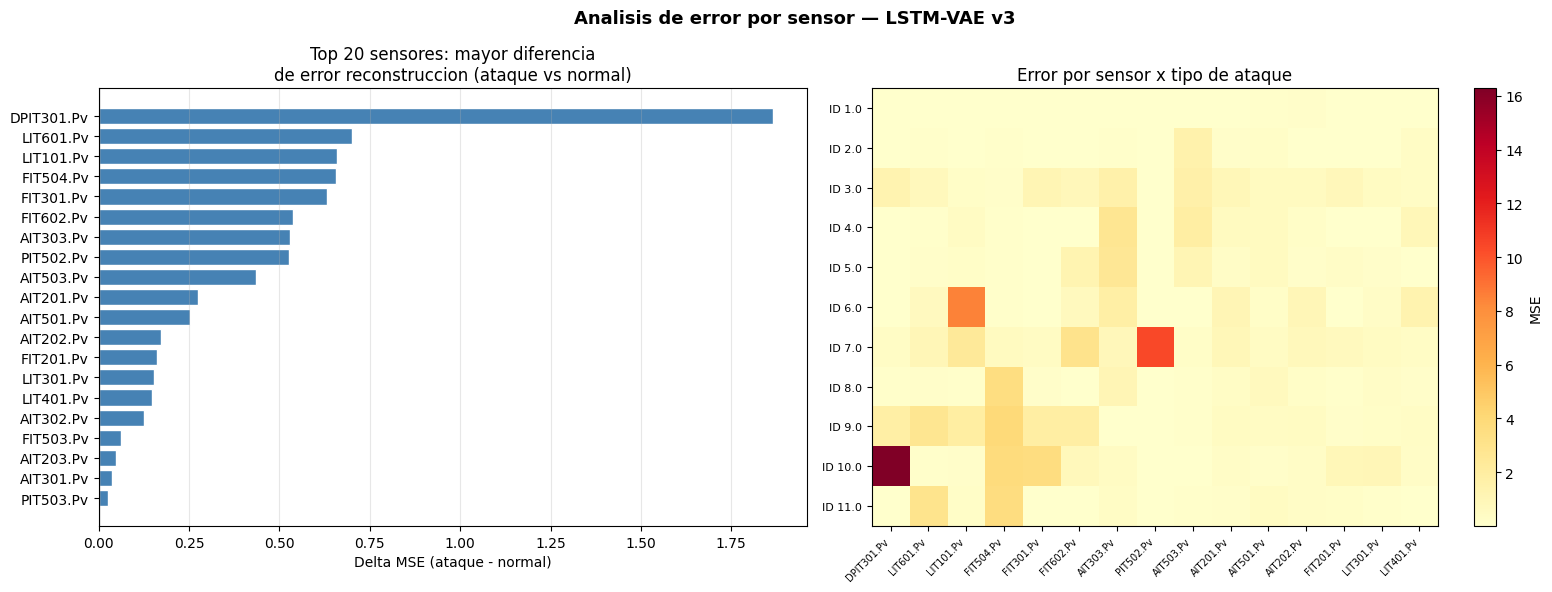

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 por delta
axes[0].barh(df_top['sensor'], df_top['delta'], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Delta MSE (ataque - normal)')
axes[0].set_title(f'Top {TOP_N} sensores: mayor diferencia\nde error reconstruccion (ataque vs normal)')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].invert_yaxis()

# Heatmap compacto: error por sensor x tipo de ataque
if 'attack_id' in df_wins.columns:
    atk_ids_uniq = sorted(df_wins[df_wins['y']==1]['attack_id'].unique())
    top_sensors  = df_top['sensor'].tolist()[:15]
    top_idx      = [continuous_cols.index(s) for s in top_sensors if s in continuous_cols]

    heat_data = np.zeros((len(atk_ids_uniq), len(top_sensors)))
    for i, aid in enumerate(atk_ids_uniq):
        mask = (df_wins['attack_id'] == aid) & (df_wins['y'] == 1)
        if mask.sum() > 0:
            heat_data[i] = ec_per_feat[mask.values][:, top_idx].mean(axis=0)

    im = axes[1].imshow(heat_data, aspect='auto', cmap='YlOrRd')
    axes[1].set_xticks(range(len(top_sensors)))
    axes[1].set_xticklabels(top_sensors, rotation=45, ha='right', fontsize=7)
    axes[1].set_yticks(range(len(atk_ids_uniq)))
    axes[1].set_yticklabels([f'ID {a}' for a in atk_ids_uniq], fontsize=8)
    axes[1].set_title('Error por sensor x tipo de ataque')
    plt.colorbar(im, ax=axes[1], label='MSE')
else:
    axes[1].text(0.5, 0.5, 'attack_id no disponible', ha='center', va='center',
                 transform=axes[1].transAxes)

plt.suptitle('Analisis de error por sensor — LSTM-VAE v3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(DIAG_DIR / 'error_por_sensor.png'), dpi=130, bbox_inches='tight')
plt.show()


## ANALISIS 5 — Score temporal

Visualizacion del score de anomalia en el tiempo superpuesto con las
etiquetas reales. Permite ver si el modelo detecta bien el inicio/fin
de los ataques, si hay retraso, o si hay segmentos normales con score alto.

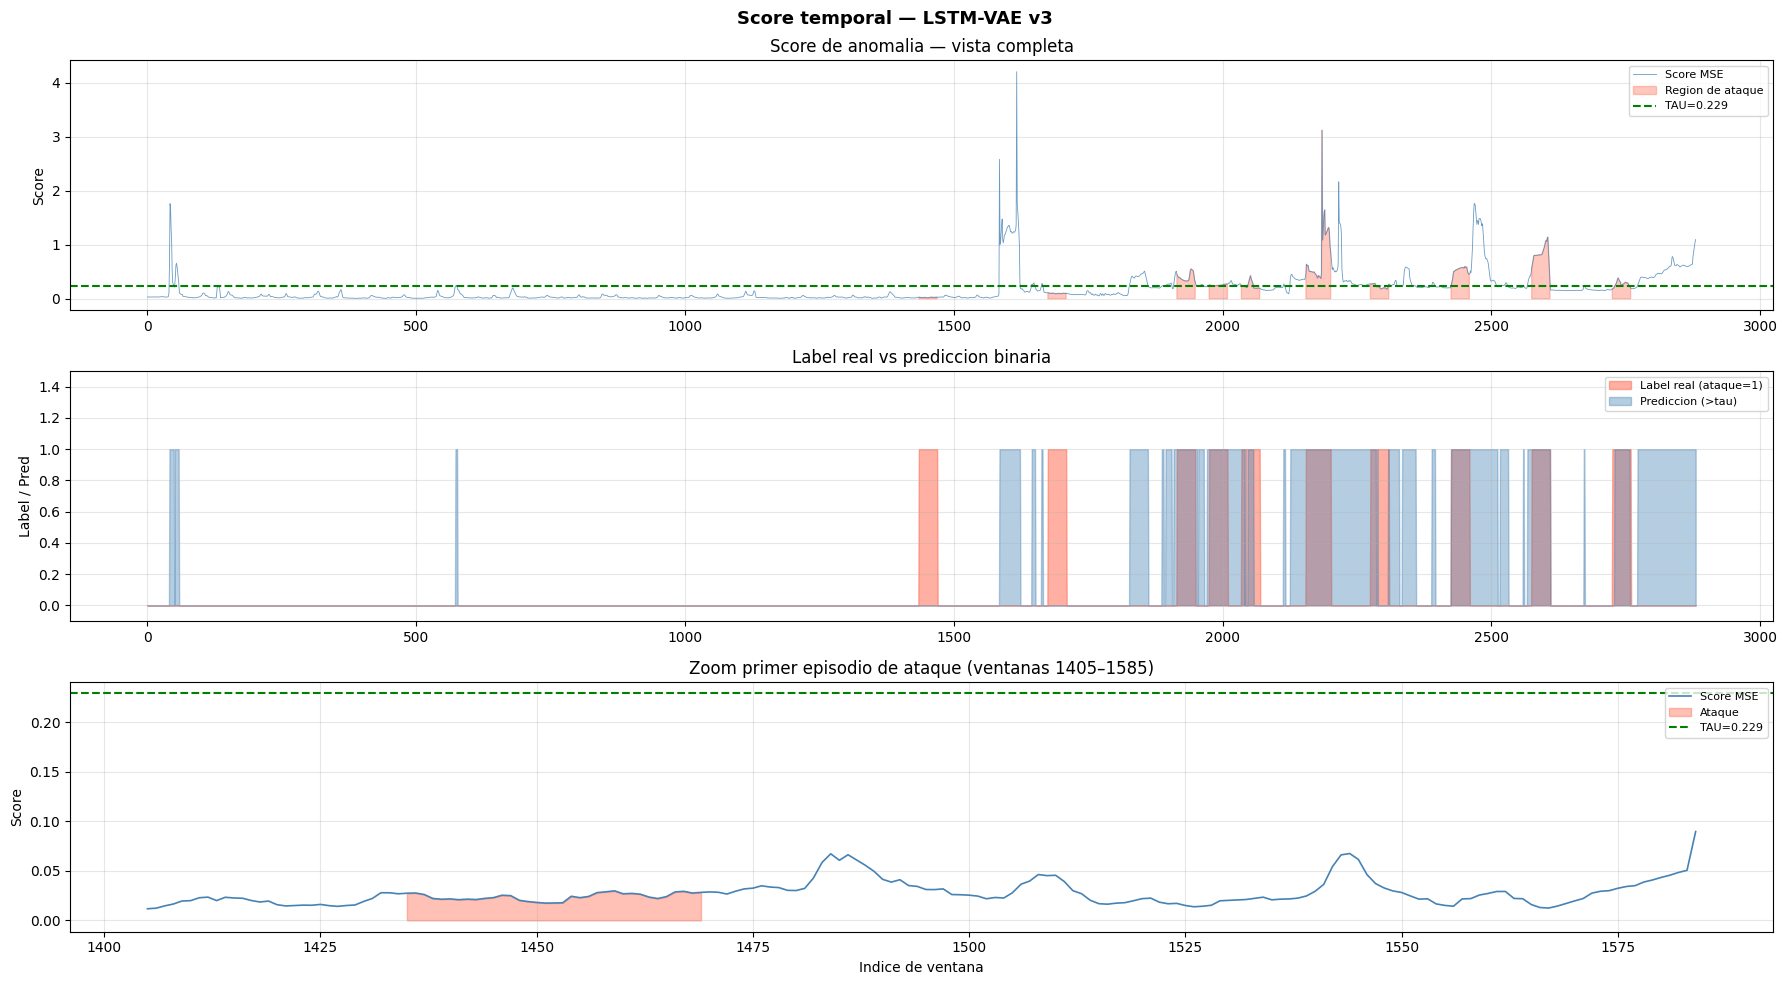

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=False)

t = np.arange(len(df_wins))  # indice de ventana como eje X
y = df_wins['y'].values

# --- Panel 1: Score completo ---
axes[0].plot(t, scores, color='steelblue', lw=0.6, alpha=0.8, label='Score MSE')
axes[0].fill_between(t, 0, scores, where=(y == 1),
                     color='tomato', alpha=0.35, label='Region de ataque')
axes[0].axhline(TAU_F1, color='green', lw=1.5, linestyle='--', label=f'TAU={TAU_F1:.3f}')
axes[0].set_ylabel('Score'); axes[0].set_title('Score de anomalia — vista completa')
axes[0].legend(loc='upper right', fontsize=8); axes[0].grid(True, alpha=0.3)

# --- Panel 2: Prediccion vs label ---
axes[1].fill_between(t, 0, y, color='tomato',    alpha=0.5, label='Label real (ataque=1)')
axes[1].fill_between(t, 0, df_wins['pred'].values,
                     color='steelblue', alpha=0.4, label='Prediccion (>tau)')
axes[1].set_ylabel('Label / Pred'); axes[1].set_title('Label real vs prediccion binaria')
axes[1].set_ylim(-0.1, 1.5)
axes[1].legend(loc='upper right', fontsize=8); axes[1].grid(True, alpha=0.3)

# --- Panel 3: Zoom en el primer episodio de ataque ---
atk_indices = np.where(y == 1)[0]
if len(atk_indices) > 0:
    first_atk  = atk_indices[0]
    zoom_start = max(0, first_atk - 30)
    zoom_end   = min(len(t), first_atk + 150)
    t_zoom = t[zoom_start:zoom_end]
    axes[2].plot(t_zoom, scores[zoom_start:zoom_end], color='steelblue', lw=1.2, label='Score MSE')
    axes[2].fill_between(t_zoom, 0, scores[zoom_start:zoom_end],
                         where=(y[zoom_start:zoom_end] == 1),
                         color='tomato', alpha=0.4, label='Ataque')
    axes[2].axhline(TAU_F1, color='green', lw=1.5, linestyle='--', label=f'TAU={TAU_F1:.3f}')
    axes[2].set_xlabel('Indice de ventana')
    axes[2].set_ylabel('Score')
    axes[2].set_title(f'Zoom primer episodio de ataque (ventanas {zoom_start}–{zoom_end})')
    axes[2].legend(loc='upper right', fontsize=8); axes[2].grid(True, alpha=0.3)
else:
    axes[2].text(0.5, 0.5, 'Sin ataques en rango', ha='center', va='center',
                 transform=axes[2].transAxes)

plt.suptitle('Score temporal — LSTM-VAE v3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(DIAG_DIR / 'score_temporal.png'), dpi=130, bbox_inches='tight')
plt.show()


## ANALISIS 6 — Score por tipo de ataque (boxplot)

Distribucion del score para cada tipo de ataque vs el score de ventanas
normales. Permite ver que tipos de ataque son intrinsecamente separables
y cuales no.

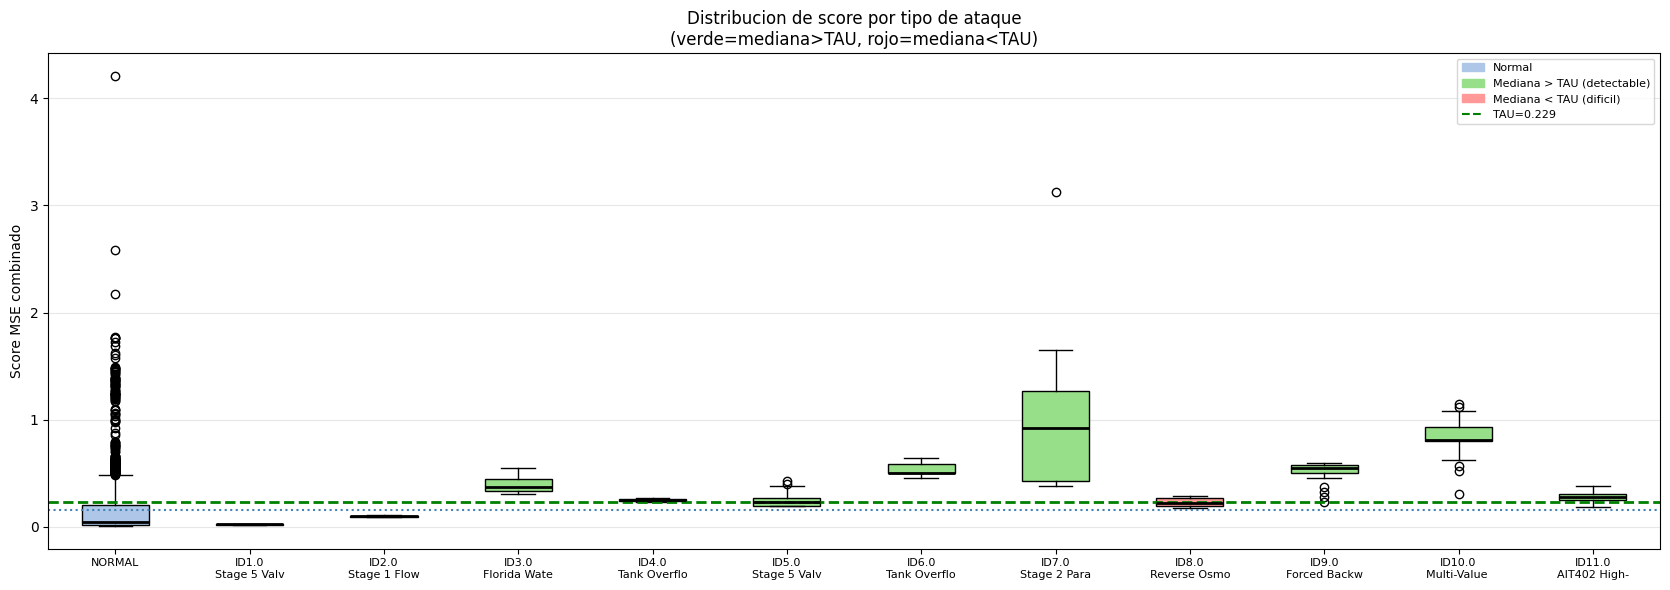

In [16]:
atk_ids_u = sorted(df_wins[df_wins['y']==1]['attack_id'].unique())
score_groups = [df_wins[df_wins['y']==0]['score'].values]  # normal primero
box_labels   = ['NORMAL']
for aid in atk_ids_u:
    grp = df_wins[df_wins['attack_id'] == aid]
    score_groups.append(grp['score'].values)
    name = grp['attack_name'].mode().iloc[0] if grp['attack_name'].nunique() > 0 else ''
    box_labels.append(f'ID{aid}\n{str(name)[:12]}')

fig, ax = plt.subplots(figsize=(max(10, len(box_labels)*1.4), 6))
bp = ax.boxplot(score_groups, patch_artist=True, notch=False,
                medianprops=dict(color='black', lw=2))

# Color: azul para normal, rojo si la mediana esta bajo TAU, verde si esta sobre
for i, (patch, grp) in enumerate(zip(bp['boxes'], score_groups)):
    if i == 0:
        patch.set_facecolor('#aec7e8')  # normal — azul claro
    elif np.median(grp) >= TAU_F1:
        patch.set_facecolor('#98df8a')  # detectable — verde
    else:
        patch.set_facecolor('#ff9896')  # dificil — rojo claro

ax.axhline(TAU_F1, color='green', linestyle='--', lw=2, label=f'TAU_F1={TAU_F1:.3f}')
ax.axhline(df_wins[df_wins['y']==0]['score'].mean(), color='steelblue',
           linestyle=':', lw=1.5, label='Score medio normal')
ax.set_xticklabels(box_labels, fontsize=8)
ax.set_ylabel('Score MSE combinado')
ax.set_title('Distribucion de score por tipo de ataque\n(verde=mediana>TAU, rojo=mediana<TAU)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

blue_p  = mpatches.Patch(color='#aec7e8', label='Normal')
green_p = mpatches.Patch(color='#98df8a', label='Mediana > TAU (detectable)')
red_p   = mpatches.Patch(color='#ff9896', label='Mediana < TAU (dificil)')
ax.legend(handles=[blue_p, green_p, red_p,
                   plt.Line2D([0],[0], color='green', linestyle='--', label=f'TAU={TAU_F1:.3f}')],
          fontsize=8)

plt.tight_layout()
plt.savefig(str(DIAG_DIR / 'score_boxplot_por_tipo.png'), dpi=130, bbox_inches='tight')
plt.show()


## ANALISIS 7 — Ataques "invisibles": que los hace diferentes

Para los ataques con tasa de deteccion < 30%: comparar la distribucion
de los sensores objetivo con el resto de ataques. Si los valores de los
sensores atacados no se alejan de su distribucion normal, el modelo no
puede detectarlos.

Ataques dificiles (<30% deteccion): [1.0, 2.0]
Ataques faciles (>=60% deteccion):  [11.0, 4.0, 6.0, 3.0, 7.0, 9.0, 10.0]


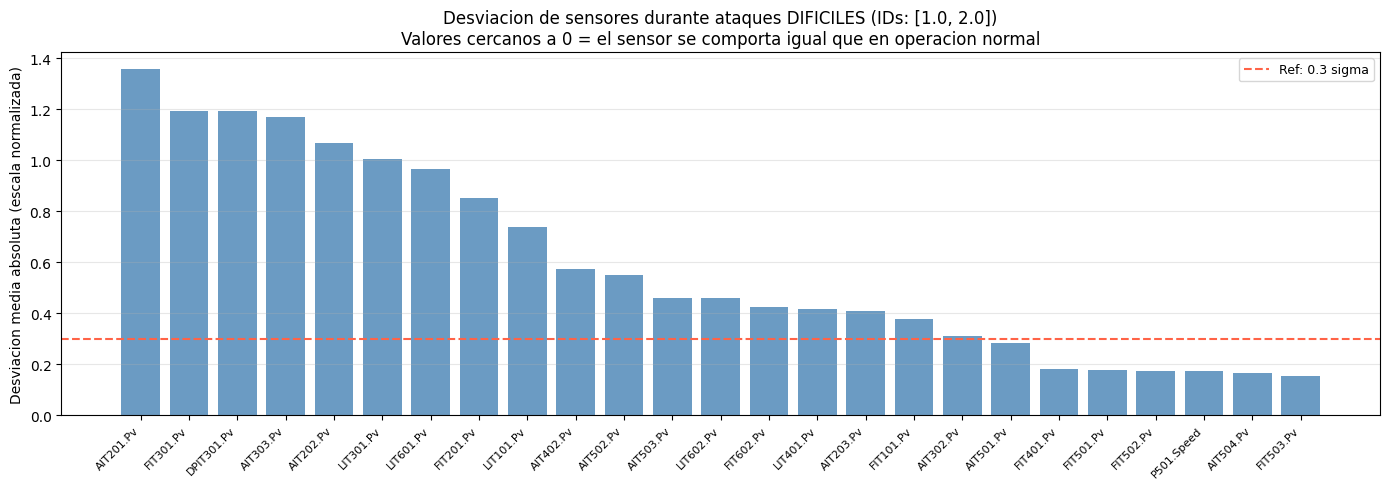


Top 10 sensores con mayor desviacion en ataques dificiles:
    sensor  dev_hard
 AIT201.Pv  1.356893
 FIT301.Pv  1.194370
DPIT301.Pv  1.194218
 AIT303.Pv  1.169567
 AIT202.Pv  1.070149
 LIT301.Pv  1.006068
 LIT601.Pv  0.967887
 FIT201.Pv  0.852374
 LIT101.Pv  0.739704
 AIT402.Pv  0.574250


In [17]:
# Identificar ataques con deteccion baja
hard_attacks = df_det[df_det['det_rate'] < 0.3]['attack_id'].tolist()
easy_attacks = df_det[df_det['det_rate'] >= 0.6]['attack_id'].tolist()

print(f'Ataques dificiles (<30% deteccion): {hard_attacks}')
print(f'Ataques faciles (>=60% deteccion):  {easy_attacks}')

if len(hard_attacks) > 0:
    # Para los ataques dificiles, ver cuanto se desvian los sensores
    # respecto a la distribucion normal (en espacio escalado)
    df_hard_raw = df_raw[
        df_raw['attack_label'].isin([1]) & 
        (df_raw.get('attack_id', pd.Series(dtype=int)).isin(hard_attacks) 
         if 'attack_id' in df_raw.columns else pd.Series(True, index=df_raw.index))
    ].copy()

    # Escalar los valores del tramo de ataque dificil
    hard_cont = np.clip(
        scaler_cont.transform(df_hard_raw[continuous_cols].fillna(modes_ref).values),
        -CLIP_VAL, CLIP_VAL
    )

    # Media absoluta de desviacion respecto a media normal (que es ~0 tras StandardScaler)
    dev_hard = np.abs(hard_cont).mean(axis=0)

    df_dev = pd.DataFrame({'sensor': continuous_cols, 'dev_hard': dev_hard}).sort_values('dev_hard', ascending=False)

    fig, ax = plt.subplots(figsize=(14, 5))
    top_dev = df_dev.head(25)
    bars = ax.bar(range(len(top_dev)), top_dev['dev_hard'], color='steelblue', alpha=0.8)
    ax.set_xticks(range(len(top_dev)))
    ax.set_xticklabels(top_dev['sensor'].tolist(), rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Desviacion media absoluta (escala normalizada)')
    ax.set_title(f'Desviacion de sensores durante ataques DIFICILES (IDs: {hard_attacks})\n'
                 f'Valores cercanos a 0 = el sensor se comporta igual que en operacion normal')
    ax.axhline(0.3, color='tomato', linestyle='--', lw=1.5, label='Ref: 0.3 sigma')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(str(DIAG_DIR / 'desviacion_ataques_dificiles.png'), dpi=130, bbox_inches='tight')
    plt.show()

    print('\nTop 10 sensores con mayor desviacion en ataques dificiles:')
    print(df_dev.head(10).to_string(index=False))
else:
    print('No hay ataques con deteccion < 30% — todos los tipos tienen buena deteccion.')


## RESUMEN FINAL — Conclusiones y recomendaciones

Esta celda consolida los hallazgos de los 7 analisis en un resumen accionable.

In [18]:
print('=' * 65)
print('RESUMEN DIAGNOSTICO — LSTM-VAE v3 (A12)')
print('=' * 65)
print(f'ROC-AUC global     : {auc:.4f}')
print(f'F1 @ TAU_F1max     : {f1:.3f}')
print(f'Recall             : {rec:.3f}')
print(f'Precision          : {prec:.3f}')
print(f'FPR                : {fpr:.3f}')
print()

print('--- TIPOS DE ATAQUE ---')
print(f'Total tipos: {len(df_det)}')
n_facil  = (df_det['det_rate'] >= 0.6).sum()
n_medio  = ((df_det['det_rate'] >= 0.3) & (df_det['det_rate'] < 0.6)).sum()
n_dificil= (df_det['det_rate'] < 0.3).sum()
print(f'  Detectables (>=60%): {n_facil}')
print(f'  Medios (30-60%):     {n_medio}')
print(f'  Dificiles (<30%):    {n_dificil}')
print()

print('--- DILUSION POR VENTANA ---')
pct_diluido = (df_atk_wins['attack_frac'] < 0.5).mean()
print(f'  Ventanas de ataque con <50% contaminacion: {pct_diluido:.1%}')
corr_frac = df_atk_wins[['attack_frac','score']].corr().iloc[0,1]
print(f'  Correlacion attack_frac vs score:          {corr_frac:.3f}')
if abs(corr_frac) > 0.3:
    print('  -> Dilusion contribuye a las fallas. Un stride menor o ventana mas corta podria ayudar.')
else:
    print('  -> Dilusion no es el principal problema.')
print()

print('--- TOP SENSORES MAS INFORMATIVOS ---')
for _, row in df_sensor.head(5).iterrows():
    print(f'  {row["sensor"]:<20} delta={row["delta"]:+.4f}  ratio={row["ratio"]:.2f}x')
print()

print('--- RECOMENDACIONES ---')
if n_dificil > 0:
    print(f'1. {n_dificil} tipos de ataque son intrinsecamente dificiles. Revisar si los')
    print('   sensores objetivo estan en continuous_cols y si sus desviaciones son detectables.')
if pct_diluido > 0.4:
    print('2. Alto % de dilusion. Considerar stride = 1 (maximo solapamiento) o')
    print('   window_size mas pequeno (ej. 30s) para los proximos experimentos.')
if fpr > 0.2:
    print('3. FPR alto. Revisar si hay periodos de transicion normal que el modelo')
    print('   confunde con ataques (arranque, cambios de setpoint, etc.).')
print()
print(f'Figuras guardadas en: {DIAG_DIR}')
print('=' * 65)


RESUMEN DIAGNOSTICO — LSTM-VAE v3 (A12)
ROC-AUC global     : 0.7963
F1 @ TAU_F1max     : 0.440
Recall             : 0.685
Precision          : 0.324
FPR                : 0.206

--- TIPOS DE ATAQUE ---
Total tipos: 11
  Detectables (>=60%): 7
  Medios (30-60%):     2
  Dificiles (<30%):    2

--- DILUSION POR VENTANA ---
  Ventanas de ataque con <50% contaminacion: 11.0%
  Correlacion attack_frac vs score:          0.088
  -> Dilusion no es el principal problema.

--- TOP SENSORES MAS INFORMATIVOS ---
  DPIT301.Pv           delta=+1.8663  ratio=33.40x
  LIT601.Pv            delta=+0.7012  ratio=8.60x
  LIT101.Pv            delta=+0.6594  ratio=3.86x
  FIT504.Pv            delta=+0.6577  ratio=1.76x
  FIT301.Pv            delta=+0.6317  ratio=10.67x

--- RECOMENDACIONES ---
1. 2 tipos de ataque son intrinsecamente dificiles. Revisar si los
   sensores objetivo estan en continuous_cols y si sus desviaciones son detectables.
3. FPR alto. Revisar si hay periodos de transicion normal que el 